Foundations of Data Science
##Data science end-to-end scenario



```
These tutorials present a complete end-to-end scenario in data science experience. They cover each step, from

*   Data ingestion

*   Data cleaning

*   Data preparation

to

*   Machine learning model training

*   **Insight** generation
```




#Introduction
A data science project lifecycle typically includes these steps:


1.   Ask questions
2.   Data Collection
3.   Data Exploration
4.   Data Modeling
5.   Data Analysis
6.   Visualization and Presentation of Results

# Part 1 : Data

## What are data?

“A datum is a single measurement of something on a scale that is
understandable to both the recorder and the reader. Data are
multiple such measurements.”

Claim: everything is (can be) data!

## Where do data come from?

•   **Internal sources**: already collected by or is part of the overall data
collection of you organization.
For example: business-centric data that is available in the organization
data base to record day to day operations; scientific or experimental
data

•   **Existing External Sources**: available in ready to read format from an
outside source for free or for a fee.
For example: public government databases, stock market data, Yelp
reviews, [your favorite sport]-reference

•   **External Sources Requiring Collection Efforts**: available from external
source but acquisition requires special processing.
For example: data appearing only in print form, or data on websites

## Ways to gather online data

How to get data generated, published or hosted online:

•   **API (Application Programming Interface)**: using a prebuilt set of
functions developed by a company to access their services. Often
pay to use. For example: Google Map API, Facebook API, Twitter
API

•   **RSS (Rich Site Summary)**: summarizes frequently updated online
content in standard format. Free to read if the site has one. For
example: news-related sites, blogs

•   **Web scraping**: using software, scripts or by-hand extracting data
from what is displayed on a page or what is contained in the HTML
file.

## Types of data

What kind of values are in your data (data types)?

**Simple or atomic:**

• Numeric: integers, floats

• Boolean: binary or true false values

• Strings: sequence of symbols

What kind of values are in your data (data types)? Compound,

**composed of a bunch of atomic types:**

• Date and time: compound value with a specific structure

• Lists: a list is a sequence of values

• Dictionaries: A dictionary is a collection of key-value pairs, a pair
of values x : y where x is usually a string called the key
representing the “name” of the entry, and y is a value of any type.
Example: Student record: what are x and y?

• First: Kevin

• Last: Rader

• Classes: [ECE333, GCS182]

## Data storage

How is your data represented and stored (data format)?

• **Tabular Data**: a dataset that is a two-dimensional table, where
each row typically represents a single data record, and each
column represents one type of measurement (csv, dat, xlsx, etc.).

• **Structured Data**: each data record is presented in a form of a
[possibly complex and multi-tiered] dictionary (json, xml, etc.)

• **Semistructured Data**: not all records are represented by the same
set of keys or some data records are not represented using the
key-value pair structure.

## Data format

How is your data represented and stored (data format)?

• Textual Data

• Temporal Data

• Geolocation Data

### Tabular Data

In tabular data, we expect each record or observation to represent a set of
measurements of a single object or event.

Each type of measurement is called a **variable** or an **attribute** of the data (e.g.
seq_id, status and duration are variables or attributes). The number of
attributes is called the **dimension**. These are often called **features**.
We expect each table to contain a set of records or observations of the same
kind of object or event

We’ll see later that it’s important to distinguish between classes of
variables or attributes based on the type of values they can take on.

• Quantitative variable: is numerical and can be either:

• discrete - a finite number of values are possible in any bounded
interval. For example: “Number of siblings” is a discrete variable

• continuous - an infinite number of values are possible in any
bounded interval. For example: “Height” is a continuous variable

• Categorical variable: no inherent order among the values For example:
“What kind of pet you have” is a categorical variable

## Common Issues

Common issues with data:

• Missing values: how do we fill in?

• Wrong values: how can we detect and correct?

• Messy format

• Not usable: the data cannot answer the question posed

# Tutorial: Data Science Process in Python (Hands-On for ECE Students)

Data science end-to-end scenario

In [29]:
## RUN THIS CELL TO PROPERLY HIGHLIGHT THE EXERCISES
import requests
from IPython.core.display import HTML


In [30]:
import pandas as pd
import sys
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
import datetime
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set(style="ticks")
%matplotlib inline

# Step 1: Scoping the Problem

1.Define the Objective

Ask: What engineering question are we solving?

**Can we predict household energy consumption based on voltage and current?**

2. Identify Inputs and Outputs

**Inputs (features)**: what data we can measure.

Voltage, current, temperature, signal strength, sensor readings.

**Output (target)**: what we want to predict.

Energy consumed, failure detection, classification label, forecasted signal.

3. Determine Problem Type

**Regression** → Predict a continuous value (e.g., energy consumption in kWh).

**Classification** → Predict a category (e.g., device “normal” vs. “faulty”).

**Clustering/Anomaly Detection **→ Find unusual patterns in sensor signals.

**Time Series Forecasting** → Predict future values (e.g., next 24h power usage).

4. Translate to a Data Science Task

**Problem statement**: We want to build a model to predict household power consumption given voltage and current measurements.

**Data science task**: Regression (continuous prediction).

**Why it matters**: Helps optimize energy usage, detect anomalies, and design smart grids.



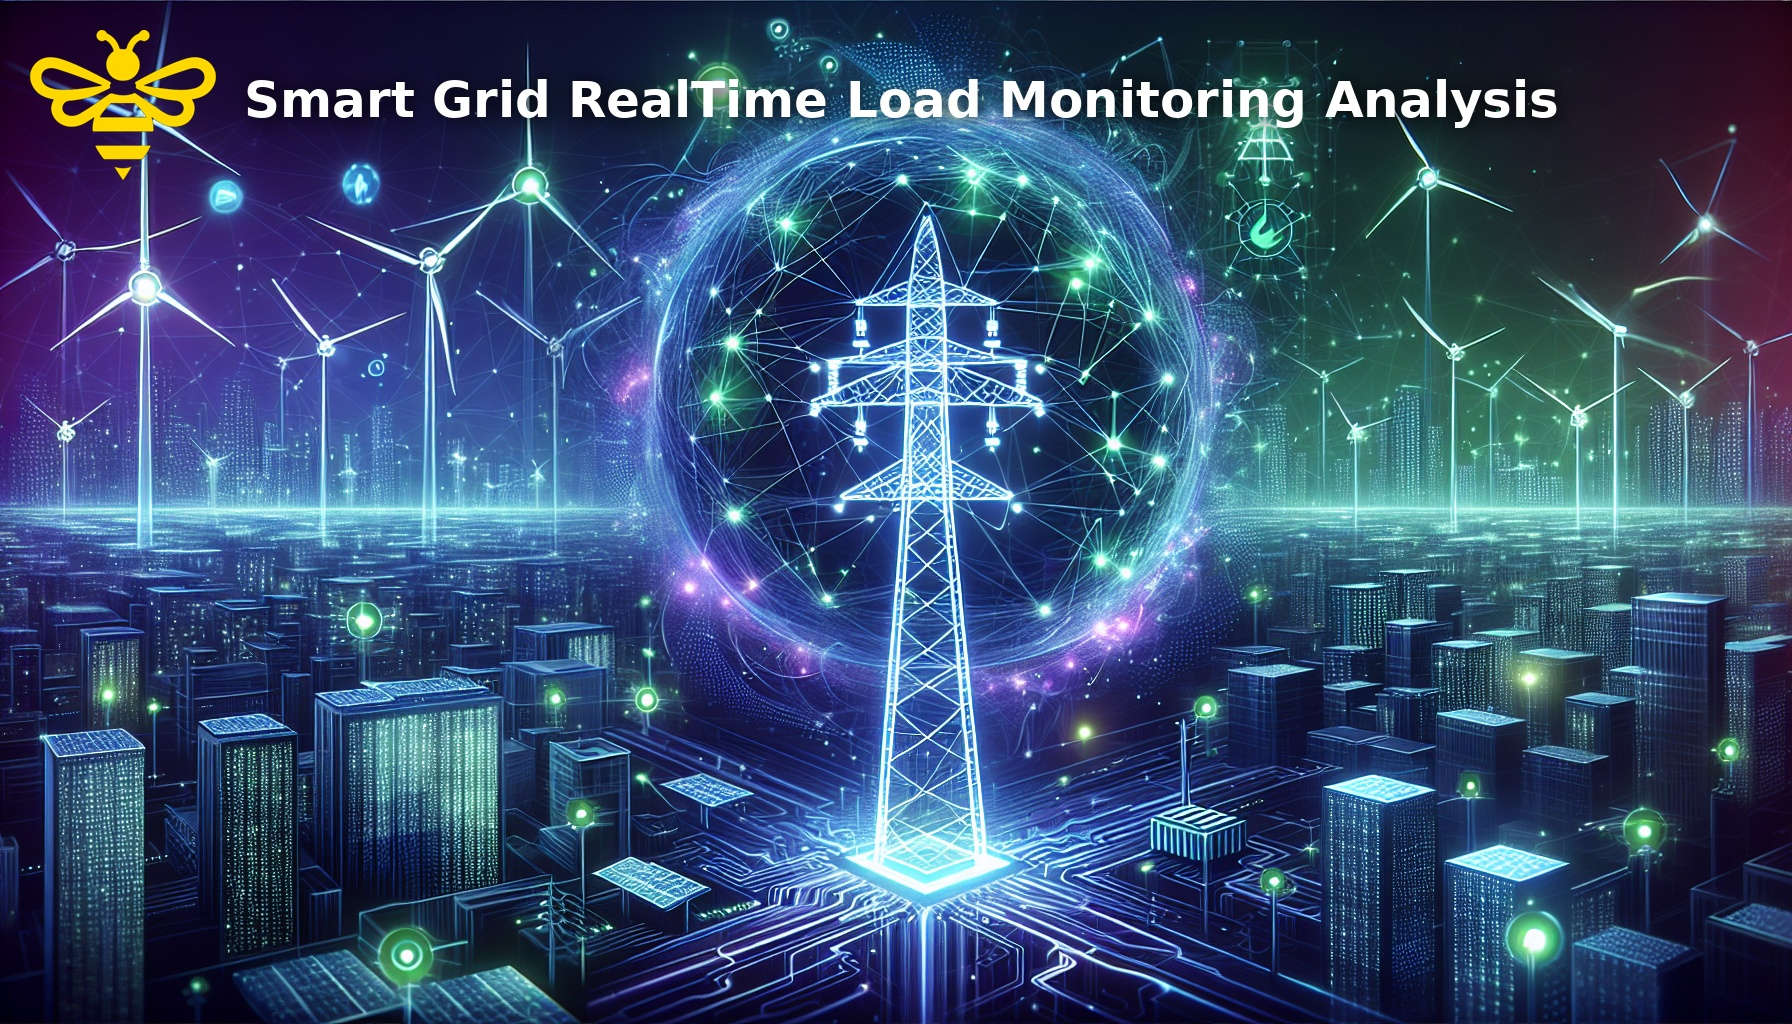



## Step 2: Data Collection/Acquisition





You can read the data from the drive

In [31]:
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# 2. Define the path (adjust to where your file is located inside Drive)
file_path = '/content/drive/MyDrive/AdvancedAI_Lab/household_power_consumption.txt'

# 3. Load the dataset
df = pd.read_csv(file_path, sep=';', engine='python', on_bad_lines='skip')

# 4. Display first 5 rows
print(df.head())

#Or I can

#df = pd.read_csv("/content/household_power_consumption.txt", sep=';', engine='python', on_bad_lines='skip')
#print(df.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


# Step 3: Data Exploration (EDA)

Goal: Understand patterns and detect problems.

Check structure: number of rows, columns, data types.

Look for missing values: is the data complete?

Basic statistics: mean, median, variance of Voltage, Current, Power.

Visualization:

Histogram of power usage (how is consumption distributed?).

Scatter plot Voltage vs Power (do they correlate?).

Time series plot (consumption over time).


In [33]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None
       Sub_metering_3
count    2.049280e+06
mean     6.458447e+00
std      8.437154e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.700000e+01
max      3.100000e+01


In [34]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())



Shape: (2075259, 9)

Data types:
 Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

Missing values:
 Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [35]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)  # Optional: drop rows with missing values


In [36]:
cols_to_convert = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2'
]

df[cols_to_convert] = df[cols_to_convert].astype(float)


In [37]:
print(df.columns.tolist())



['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [38]:
# Set a fixed start date
start_date = "2006-12-16"

# Combine with Time column
df['Datetime'] = pd.to_datetime(start_date + ' ' + df['Time'])

df['Datetime'] = pd.date_range(start=start_date + ' ' + df['Time'].iloc[0], periods=len(df), freq='T')
df.set_index('Datetime', inplace=True)
df.drop('Time', axis=1, inplace=True)


/tmp/ipython-input-203251711.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['Datetime'] = pd.date_range(start=start_date + ' ' + df['Time'].iloc[0], periods=len(df), freq='T')


In [39]:
print(df.dtypes)
print(df.head())


Date                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
                           Date  Global_active_power  Global_reactive_power  \
Datetime                                                                      
2006-12-16 17:24:00  16/12/2006                4.216                  0.418   
2006-12-16 17:25:00  16/12/2006                5.360                  0.436   
2006-12-16 17:26:00  16/12/2006                5.374                  0.498   
2006-12-16 17:27:00  16/12/2006                5.388                  0.502   
2006-12-16 17:28:00  16/12/2006                3.666                  0.528   

                     Voltage  Global_intensity  Sub_metering_1  \
Datetime                                                         
2006-12-16 17:24:00   234.84        

In [40]:
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df.head()

,Date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,IsWeekend
Datetime,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5,1
2006-12-16 17:25:00,16/12/2006,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5,1
2006-12-16 17:26:00,16/12/2006,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5,1
2006-12-16 17:27:00,16/12/2006,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,5,1
2006-12-16 17:28:00,16/12/2006,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,5,1


You have ~2 million rows and .......... columns.

Each row = one minute of household measurements.

This means ~4 years of continuous monitoring (2006–2010)

## EX1: Data Visualization

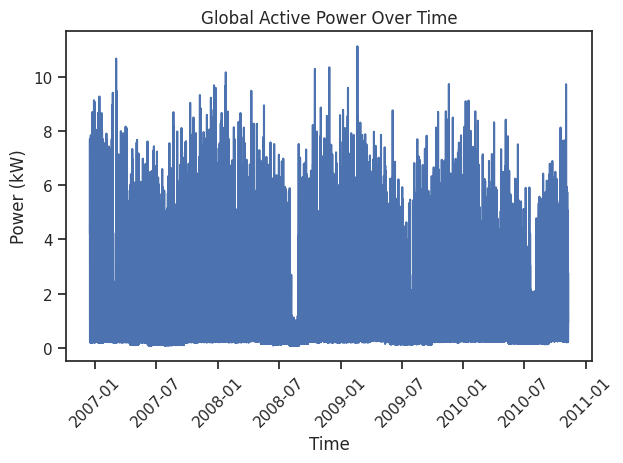

In [41]:
# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x=df.index, y='Global_active_power')
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Baseline Model

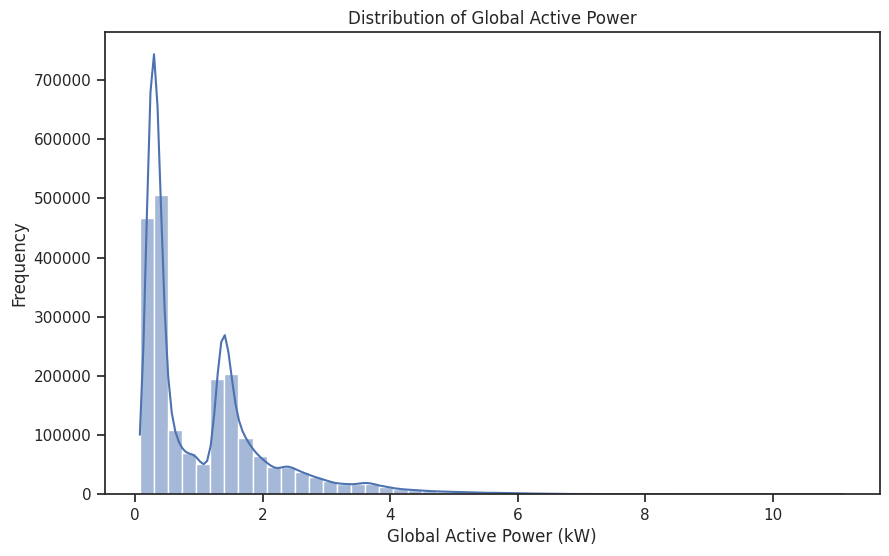

In [42]:
# Histogram of Global Active Power
#Distribution of Global Active Power
#This histogram shows the distribution of the Global_active_power variable. The distribution appears to be skewed to the right, indicating that lower power consumption values are more frequent.
plt.figure(figsize=(10, 6))
sns.histplot(df['Global_active_power'], bins=50, kde=True)
plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")
plt.show()

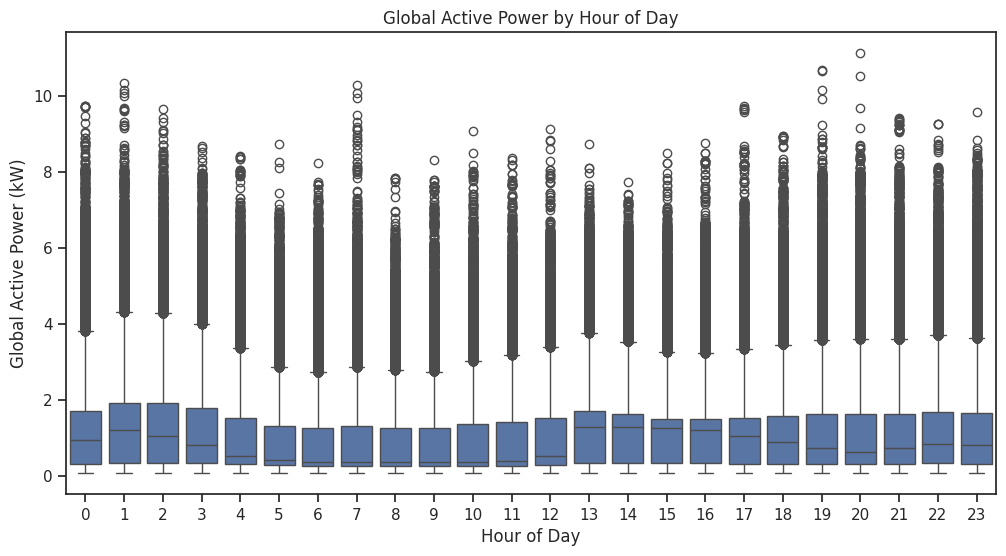

In [43]:
# Box plot of Global Active Power by Hour
#Global Active Power by Hour of Day
#This box plot visualizes the distribution of Global_active_power for each hour of the day.
#It appears that power consumption is generally higher during certain hours, likely corresponding to peak usage times. The box plot also shows the spread and potential outliers for each hour.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Hour', y='Global_active_power', data=df)
plt.title("Global Active Power by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power (kW)")
plt.show()

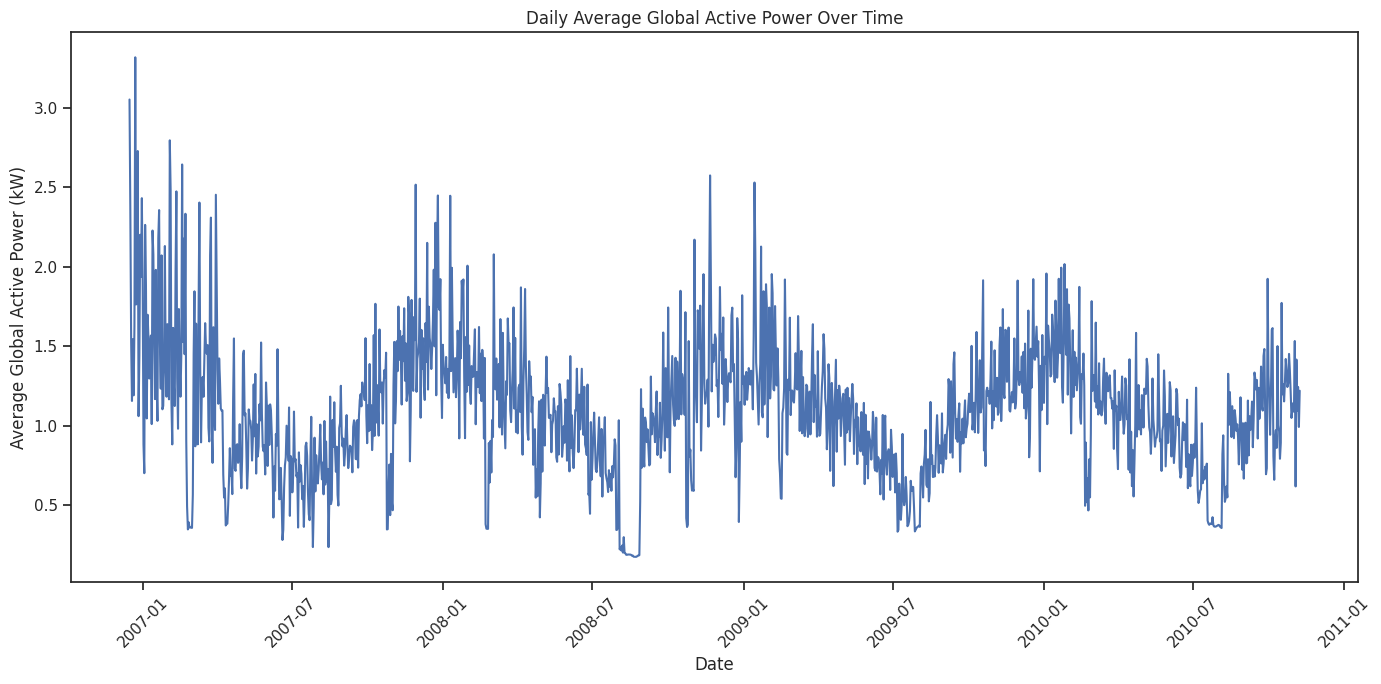

In [44]:
# Daily average Global Active Power over time
#Daily Average Global Active Power Over Time
#This line plot shows the daily average of Global_active_power over the entire period of the dataset. This helps to visualize trends and seasonality in power consumption.
daily_avg_power = df['Global_active_power'].resample('D').mean()

plt.figure(figsize=(14, 7))
sns.lineplot(x=daily_avg_power.index, y=daily_avg_power.values)
plt.title("Daily Average Global Active Power Over Time")
plt.xlabel("Date")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

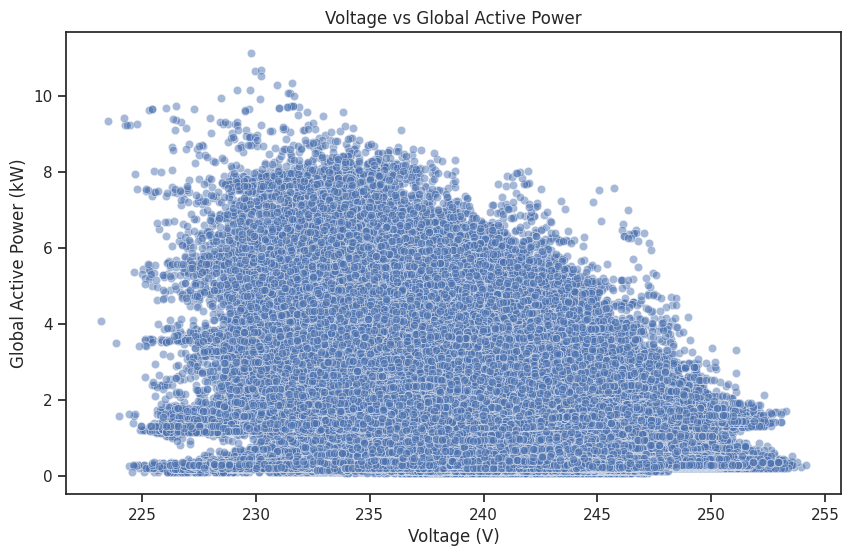

In [45]:
# Scatter plot of Voltage vs Global Active Power
# This scatter plot shows the relationship between Voltage and Global Active Power.
# It helps to visualize if there is a correlation between these two variables.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Voltage', y='Global_active_power', data=df, alpha=0.5)
plt.title("Voltage vs Global Active Power")
plt.xlabel("Voltage (V)")
plt.ylabel("Global Active Power (kW)")
plt.show()

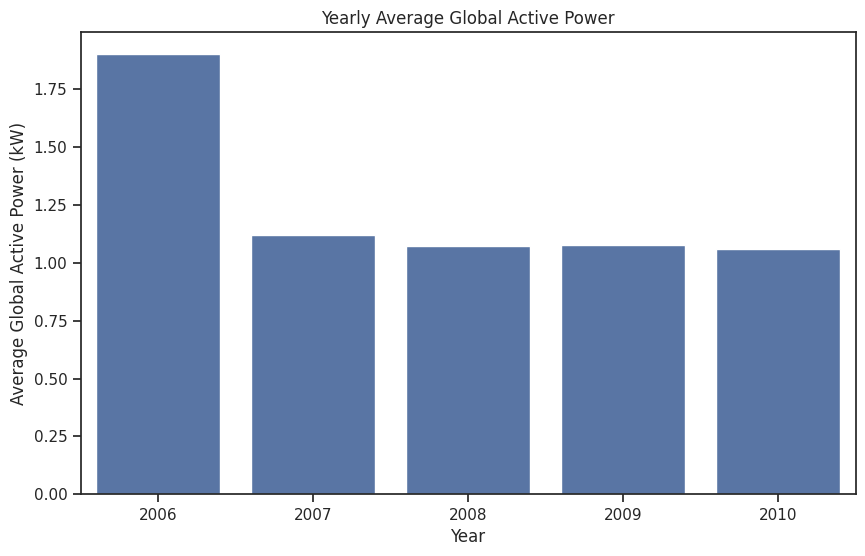

In [46]:
# Yearly average Global Active Power
# This bar plot displays the average Global Active Power for each year in the dataset.
# It provides a high-level view of how average power consumption changes year by year.
df['Year'] = df.index.year
yearly_avg = df.groupby('Year')['Global_active_power'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_avg.index, y=yearly_avg.values)
plt.title("Yearly Average Global Active Power")
plt.xlabel("Year")
plt.ylabel("Average Global Active Power (kW)")
plt.show()

##EX2: Feature Engineering

In [47]:
def is_holiday_season(date):
    month = date.month
    day = date.day
    # new years break
    if (month == 12 and day >= 25) or (month == 1 and day <= 7):
        return True
    # summer break
    if (month >= 6 and month <= 9) and not (month == 9 and day > 5):
        return True
    return False

df['HolidaySeason'] = df.index.map(is_holiday_season).astype(int)

print(df[['Date','HolidaySeason']])

                           Date  HolidaySeason
Datetime                                      
2006-12-16 17:24:00  16/12/2006              0
2006-12-16 17:25:00  16/12/2006              0
2006-12-16 17:26:00  16/12/2006              0
2006-12-16 17:27:00  16/12/2006              0
2006-12-16 17:28:00  16/12/2006              0
...                         ...            ...
2010-11-08 19:59:00  26/11/2010              0
2010-11-08 20:00:00  26/11/2010              0
2010-11-08 20:01:00  26/11/2010              0
2010-11-08 20:02:00  26/11/2010              0
2010-11-08 20:03:00  26/11/2010              0

[2049280 rows x 2 columns]


In [48]:
# Feature Engineering: Add Season feature

# Function to map month to season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Month'] = df.index.month
df['Season'] = df['Month'].apply(get_season)

# Display the first few rows with the new feature
print(df[['Month', 'Season']].head())

                     Month  Season
Datetime                          
2006-12-16 17:24:00     12  Winter
2006-12-16 17:25:00     12  Winter
2006-12-16 17:26:00     12  Winter
2006-12-16 17:27:00     12  Winter
2006-12-16 17:28:00     12  Winter


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
# X = df[['Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]
X = df.drop(columns=['Global_active_power', 'Date', 'Season'])
y = df['Global_active_power']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)



Train shape: (1639424, 12) (1639424,)
Test shape: (409856, 12) (409856,)


In [50]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['Global_active_power', 'Date', 'Season']))

# Convert the scaled array back to a DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=df.drop(columns=['Global_active_power', 'Date', 'Season']).columns)

# Display the first few rows of the scaled training data
print("Scaled Training Data:")
print(X_train.head())

# Display the first few rows of the scaled testing data
print("\nScaled Testing Data:")
print(X_test.head())

Scaled Training Data:
                     Global_reactive_power  Voltage  Global_intensity  \
Datetime                                                                
2010-10-15 19:39:00                  0.236   244.14               5.2   
2010-06-07 06:01:00                  0.084   243.73               1.8   
2010-04-08 20:49:00                  0.098   240.21               1.6   
2009-03-03 18:24:00                  0.074   244.49               7.0   
2007-04-12 00:17:00                  0.130   239.10               1.4   

                     Sub_metering_1  Sub_metering_2  Sub_metering_3  Hour  \
Datetime                                                                    
2010-10-15 19:39:00             0.0             1.0             0.0    19   
2010-06-07 06:01:00             0.0             0.0             1.0     6   
2010-04-08 20:49:00             0.0             0.0             0.0    20   
2009-03-03 18:24:00             0.0             0.0            19.0    18   
2007

In [51]:
X = pd.get_dummies(df, columns=['DayOfWeek','Month'], drop_first=True)

In [52]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Gradient Boosting Regressor model
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gbr = gbr.predict(X_test)

# Evaluate the model
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Model Evaluation with Gradient Boosting Regressor:")
print("MSE:", mse_gbr)
print("R² Score:", r2_gbr)

Model Evaluation with Gradient Boosting Regressor:
MSE: 0.001153533890397783
R² Score: 0.9989736726899853


In [53]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Ridge Regression model
ridge = Ridge(alpha=1.0) # You can tune the alpha parameter
ridge.fit(X_train, y_train)

# Make predictions on the test data
y_pred_ridge = ridge.predict(X_test)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Model Evaluation with Ridge Regression:")
print("MSE:", mse_ridge)
print("R² Score:", r2_ridge)

Model Evaluation with Ridge Regression:
MSE: 0.0016199386855702093
R² Score: 0.9985587009385768


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: title={'center': 'ARIMA Forecast: Next 24 Hours'}>

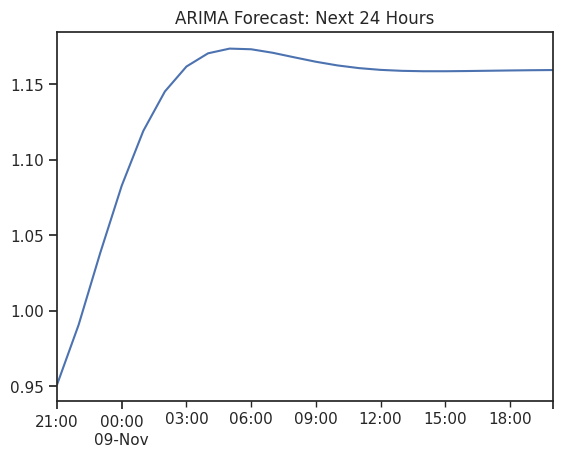

In [54]:
from statsmodels.tsa.arima.model import ARIMA

# Ensure the 'Datetime' column is the index
if not isinstance(df.index, pd.DatetimeIndex):
    # Convert 'Date' and 'Time' to datetime and set as index
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True) # Added dayfirst=True for correct parsing
    df.set_index('Datetime', inplace=True)
    df.drop(['Date', 'Time'], axis=1, inplace=True)

# Convert 'Global_active_power' to numeric, coercing errors
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Drop rows with NaN in 'Global_active_power' that resulted from coercion
df.dropna(subset=['Global_active_power'], inplace=True)


# Downsample to hourly average for smoother modeling
df_hourly = df['Global_active_power'].resample('h').mean().dropna()

# Fit ARIMA model
model = ARIMA(df_hourly, order=(2,1,2))  # You can tune (p,d,q)
results = model.fit()

# Forecast next 24 hours
forecast = results.forecast(steps=24)
forecast.plot(title='ARIMA Forecast: Next 24 Hours')

/tmp/ipython-input-3079566137.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_prophet = df['Global_active_power'].resample('H').mean().dropna().reset_index()
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxp69aomc/sgwj3oav.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxp69aomc/_h3vo7nv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80228', 'data', 'file=/tmp/tmpxp69aomc/sgwj3oav.json', 'init=/tmp/tmpxp69aomc/_h3vo7nv.json', 'output', 'file=/tmp/tmpxp69aomc/prophet_model2jorimnd/prophet_model-20250922181043.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:10:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:10:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.

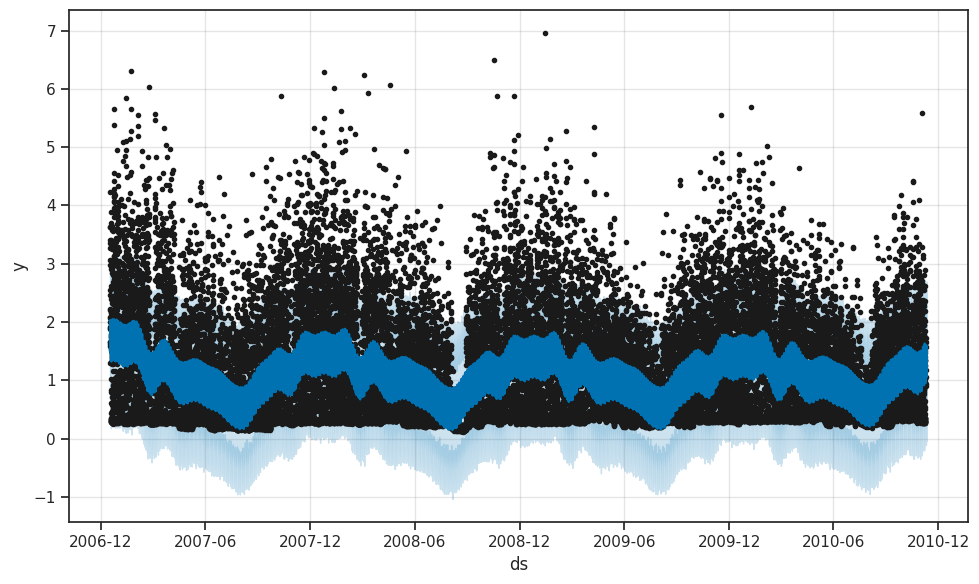

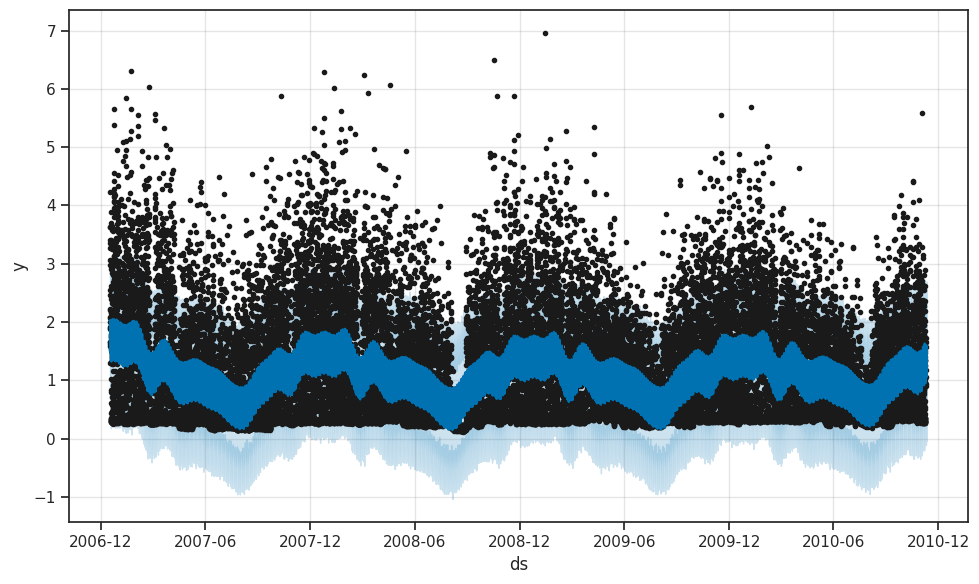

In [55]:
from prophet import Prophet

# Prepare data
df_prophet = df['Global_active_power'].resample('H').mean().dropna().reset_index()
df_prophet.columns = ['ds', 'y']

# Fit model
model = Prophet()
model.fit(df_prophet)

# Future dataframe
future = model.make_future_dataframe(periods=48, freq='H')
forecast = model.predict(future)

# Plot
model.plot(forecast)

Ex3: Evaluation Metrics

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_log_error, explained_variance_score


# For Linear Regression (using y_pred_gbr from the Gradient Boosting Regressor)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_lr = mean_absolute_error(y_test, y_pred_gbr)
msle_lr = mean_squared_log_error(y_test, y_pred_gbr)
rmsle_lr = np.sqrt(msle_lr)
explained_variance_lr = explained_variance_score(y_test, y_pred_gbr)


print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Root Mean Squared Logarithmic Error (RMSLE): {rmsle_lr:.4f}")
print(f"Explained Variance Score: {explained_variance_lr:.4f}")

Root Mean Squared Error (RMSE): 0.0340
Mean Absolute Error (MAE): 0.0211
Root Mean Squared Logarithmic Error (RMSLE): 0.0163
Explained Variance Score: 0.9990
